# 04 — Evaluation and Comparison

**Goal:** measure how well every model forecasts **NH4, COD and TSS 4 hours ahead**, compare
them against the baseline, and decide which model to actually keep.

The decision rule, agreed before looking at any result:

> **`persistence` is the model in charge.** Another model replaces it only if it is better by
> an amount large enough to survive re-testing. If nothing beats it, **we keep the baseline.**

This notebook only reads the CSV files written by notebook 03, so it runs in seconds.

## Step 1 — Imports and settings

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

SITE_NAME = {"BAY_MAU": "Bay Mau", "CAU_NGA": "Cau Nga", "HO_TAY": "Ho Tay"}
SITES = list(SITE_NAME.keys())
TARGETS = ["nh4", "cod", "tss"]

HORIZON_HOURS = 4
BASELINE = "persistence"       # the model everything else must beat

print("Comparing forecasts", HORIZON_HOURS, "hours ahead")

Comparing forecasts 4 hours ahead


## Step 2 — Load the predictions from notebook 03

In [2]:
predictions = {}
for site in SITES:
    for target in TARGETS:
        path = "predictions/" + site + "_" + target + ".csv"
        predictions[(site, target)] = pd.read_csv(path, index_col=0, parse_dates=True)

model_names = [c for c in predictions[("CAU_NGA", "nh4")].columns if c != "actual"]
print("Models to compare:", model_names)
print()
for site in SITES:
    for target in TARGETS:
        print(SITE_NAME[site], target, ":",
              len(predictions[(site, target)]), "test hours")

Models to compare: ['train_mean', 'persistence', 'seasonal_naive', 'moving_average', 'drift', 'ridge', 'gradient_boosting']

Bay Mau nh4 : 672 test hours
Bay Mau cod : 370 test hours
Bay Mau tss : 698 test hours
Cau Nga nh4 : 866 test hours
Cau Nga cod : 866 test hours
Cau Nga tss : 866 test hours
Ho Tay nh4 : 225 test hours
Ho Tay cod : 232 test hours
Ho Tay tss : 169 test hours


## Step 3 — Measure accuracy

Three standard numbers:

- **MAE** — the average size of the error, in the same units as the indicator. Lower is better.
- **RMSE** — like MAE but punishes large mistakes more. Lower is better.
- **R2** — how much of the variation the model explains. 1.0 is perfect, 0 means no better
  than always guessing the average, and negative means worse than that.

In [3]:
scores = []
for site in SITES:
    for target in TARGETS:
        table = predictions[(site, target)]
        actual = table["actual"]

        for model in model_names:
            if model not in table.columns:
                continue
            guess = table[model]
            scores.append({
                "site": SITE_NAME[site],
                "indicator": target,
                "model": model,
                "hours_tested": len(actual),
                "MAE": mean_absolute_error(actual, guess),
                "RMSE": np.sqrt(mean_squared_error(actual, guess)),
                "R2": r2_score(actual, guess),
            })

scores = pd.DataFrame(scores)
print("Accuracy of every model (lower MAE is better):")
scores.head(8).round(4)

Accuracy of every model (lower MAE is better):


,site,indicator,model,hours_tested,MAE,RMSE,R2
0,Bay Mau,nh4,train_mean,672,0.2388,0.2787,-0.3524
1,Bay Mau,nh4,persistence,672,0.0228,0.0787,0.8922
2,Bay Mau,nh4,seasonal_naive,672,0.0921,0.1906,0.3673
3,Bay Mau,nh4,moving_average,672,0.0283,0.0852,0.8736
4,Bay Mau,nh4,drift,672,0.0379,0.1143,0.7727
5,Bay Mau,nh4,ridge,672,0.0467,0.0854,0.8732
6,Bay Mau,nh4,gradient_boosting,672,0.0608,0.0971,0.8358
7,Bay Mau,cod,train_mean,370,3.6842,6.0858,-0.0822


## Step 4 — The skill score: is a model better than doing nothing?

MAE on its own is misleading. An MAE of 0.008 sounds excellent, but if `persistence` also gets
0.008 then the model has added nothing.

So for every model we compute a **skill score**:

```
skill = 1 - (MAE of the model) / (MAE of persistence)
```

- **skill above 0** means better than assuming no change
- **skill of 0** means exactly as good as doing nothing
- **skill below 0** means worse than doing nothing

In [4]:
# Find the baseline MAE for each site and indicator, then compare everything to it.
baseline_mae = (scores[scores.model == BASELINE]
                .set_index(["site", "indicator"])["MAE"])

scores["baseline_MAE"] = scores.set_index(["site", "indicator"]).index.map(baseline_mae).values
scores["skill"] = 1 - scores["MAE"] / scores["baseline_MAE"]

# Sanity check: the baseline compared with itself must score exactly zero.
assert np.allclose(scores.loc[scores.model == BASELINE, "skill"], 0)
print("Check passed: the baseline scores a skill of exactly 0 against itself.")
print()

for target in TARGETS:
    print("=" * 78)
    print("  INDICATOR:", target, " (forecast", HORIZON_HOURS, "hours ahead)")
    print("=" * 78)
    display(scores[scores.indicator == target]
            .sort_values(["site", "MAE"])
            .set_index(["site", "model"])[["hours_tested", "MAE", "RMSE", "R2", "skill"]]
            .round(4))

Check passed: the baseline scores a skill of exactly 0 against itself.

  INDICATOR: nh4  (forecast 4 hours ahead)


hours_tested     MAE    RMSE      R2    skill
site    model                                                           
Bay Mau persistence                 672  0.0228  0.0787  0.8922   0.0000
        moving_average              672  0.0283  0.0852  0.8736  -0.2426
        drift                       672  0.0379  0.1143  0.7727  -0.6632
        ridge                       672  0.0467  0.0854  0.8732  -1.0454
        gradient_boosting           672  0.0608  0.0971  0.8358  -1.6675
        seasonal_naive              672  0.0921  0.1906  0.3673  -3.0388
        train_mean                  672  0.2388  0.2787 -0.3524  -9.4691
Cau Nga persistence                 866  0.0586  0.1391  0.9671   0.0000
        ridge                       866  0.0710  0.1398  0.9667  -0.2116
        moving_average              866  0.0735  0.1524  0.9605  -0.2540
        drift                       866  0.0852  0.1946  0.9355  -0.4537
        gradient_boosting           866  0.1322  0.2304  0.9096  -1.2553
        seasonal_naive              866  0.1964  0.3235  0.8219  -2.3504
        train_mean                  866  0.6964  0.8332 -0.1817 -10.8796
Ho Tay  persistence                 225  0.0078  0.0106  0.9932   0.0000
        moving_average              225  0.0090  0.0116  0.9918  -0.1478
        drift                       225  0.0107  0.0143  0.9876  -0.3656
        ridge                       225  0.0115  0.0150  0.9864  -0.4703
        seasonal_naive              225  0.0248  0.0298  0.9459  -2.1644
        gradient_boosting           225  0.0792  0.0926  0.4785  -9.1168
        train_mean                  225  0.3616  0.3836 -7.9517 -45.1987

  INDICATOR: cod  (forecast 4 hours ahead)


hours_tested     MAE    RMSE       R2    skill
site    model                                                            
Bay Mau gradient_boosting           370  2.0523  4.8085   0.3244   0.0703
        persistence                 370  2.2074  5.3028   0.1784   0.0000
        ridge                       370  2.4759  4.9938   0.2713  -0.1216
        moving_average              370  2.5399  5.3921   0.1505  -0.1506
        drift                       370  3.5245  8.2477  -0.9876  -0.5967
        train_mean                  370  3.6842  6.0858  -0.0822  -0.6690
        seasonal_naive              370  4.6170  7.5415  -0.6618  -1.0916
Cau Nga persistence                 866  0.7145  1.1962   0.7733   0.0000
        moving_average              866  0.8376  1.3097   0.7283  -0.1723
        drift                       866  1.0651  1.7301   0.5258  -0.4907
        ridge                       866  1.4117  1.7539   0.5127  -0.9757
        seasonal_naive              866  1.5433  1.9652   0.3882  -1.1598
        gradient_boosting           866  1.5725  2.2437   0.2025  -1.2008
        train_mean                  866  6.1573  6.6198  -5.9419  -7.6174
Ho Tay  moving_average              232  0.0697  0.1706   0.8418   0.0432
        persistence                 232  0.0729  0.2069   0.7673   0.0000
        drift                       232  0.1242  0.3540   0.3185  -0.7051
        seasonal_naive              232  0.1339  0.2327   0.7055  -0.8383
        gradient_boosting           232  0.3721  0.5248  -0.4975  -4.1079
        ridge                       232  0.4518  0.4916  -0.3143  -5.2021
        train_mean                  232  1.5066  1.5630 -12.2841 -19.6795

  INDICATOR: tss  (forecast 4 hours ahead)


hours_tested     MAE    RMSE         R2     skill
site    model                                                               
Bay Mau persistence                 698  1.4857  4.1531     0.1095    0.0000
        moving_average              698  1.7580  4.4266    -0.0117   -0.1833
        gradient_boosting           698  2.0512  3.8021     0.2536   -0.3806
        ridge                       698  2.0852  3.7245     0.2838   -0.4034
        drift                       698  2.3487  6.5289    -1.2009   -0.5808
        seasonal_naive              698  2.8856  5.9099    -0.8033   -0.9422
        train_mean                  698  3.2335  4.5494    -0.0686   -1.1764
Cau Nga gradient_boosting           866  2.3718  3.4400     0.4311    0.1940
        ridge                       866  2.4982  3.7986     0.3063    0.1510
        persistence                 866  2.9427  4.5311     0.0129    0.0000
        seasonal_naive              866  2.9996  4.3771     0.0789   -0.0193
        moving_average              866  3.2449  4.6821    -0.0540   -0.1027
        train_mean                  866  3.4856  4.7824    -0.0996   -0.1845
        drift                       866  4.1393  6.8966    -1.2867   -0.4066
Ho Tay  moving_average              169  0.0103  0.0129     0.9383    0.1732
        persistence                 169  0.0125  0.0157     0.9090    0.0000
        drift                       169  0.0217  0.0261     0.7481   -0.7388
        seasonal_naive              169  0.0239  0.0316     0.6297   -0.9125
        gradient_boosting           169  0.5644  0.5665  -117.9348  -44.1975
        ridge                       169  0.7282  0.7385  -201.1734  -57.3172
        train_mean                  169  1.8381  1.8389 -1252.3999 -146.1965

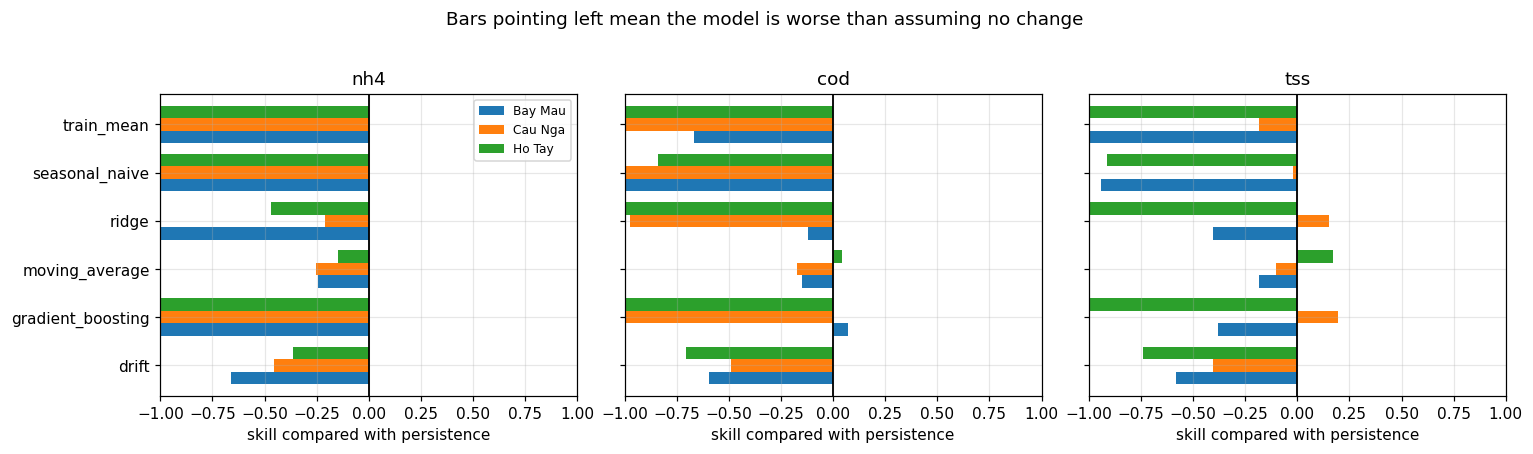

In [5]:
# A picture of the same thing. Anything left of the black line lost to the baseline.
figure, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for axis, target in zip(axes, TARGETS):
    part = scores[(scores.indicator == target) & (scores.model != BASELINE)]
    chart = part.pivot_table(index="model", columns="site", values="skill")
    chart.plot(kind="barh", ax=axis, width=0.78, legend=(target == TARGETS[0]))

    axis.axvline(0, color="black", linewidth=1.2)
    axis.set_xlim(-1, 1)
    axis.set_title(target)
    axis.set_xlabel("skill compared with persistence")
    axis.set_ylabel("")

axes[0].legend(fontsize=8)
plt.suptitle("Bars pointing left mean the model is worse than assuming no change", y=1.02)
plt.tight_layout()
plt.show()

## Step 5 — Is the improvement real, or just luck?

A model might beat the baseline on this particular test period purely by chance. Before
trusting a positive skill score we check whether it would survive if the test period had been
slightly different.

The method is a **bootstrap**: take the test hours, draw a random sample of the same size with
repeats, recompute the skill, and repeat 2,000 times. That gives a range of plausible skill
scores. We only accept a model if the **entire range stays above zero**.

The same random rows are used for the model and for the baseline each time, so we compare them
under identical conditions.

In [6]:
RANDOM = np.random.default_rng(42)
NUMBER_OF_SAMPLES = 2000


def skill_range(actual, guess, baseline_guess):
    """Return the plausible range (2.5% to 97.5%) of the skill score."""
    model_errors = np.abs(actual - guess)
    baseline_errors = np.abs(actual - baseline_guess)

    # 2000 random samples of row positions, drawn with repeats.
    picks = RANDOM.integers(0, len(actual), size=(NUMBER_OF_SAMPLES, len(actual)))

    model_mae = model_errors[picks].mean(axis=1)
    baseline_mae = baseline_errors[picks].mean(axis=1)
    all_skills = 1 - model_mae / baseline_mae

    return np.percentile(all_skills, [2.5, 97.5])


checks = []
for site in SITES:
    for target in TARGETS:
        table = predictions[(site, target)]
        actual = table["actual"].values
        baseline_guess = table[BASELINE].values

        for model in model_names:
            if model == BASELINE or model not in table.columns:
                continue

            low, high = skill_range(actual, table[model].values, baseline_guess)
            skill = 1 - (mean_absolute_error(actual, table[model])
                         / mean_absolute_error(actual, baseline_guess))

            checks.append({
                "site": SITE_NAME[site], "indicator": target, "model": model,
                "hours_tested": len(actual),
                "skill": skill, "lowest_likely": low, "highest_likely": high,
                "really_better": bool(low > 0),
            })

checks = pd.DataFrame(checks)
winners = checks[checks.really_better]

print(len(winners), "of", len(checks), "models are genuinely better than the baseline")
print("(their whole plausible range stays above zero)")
print()
display(winners.set_index(["site", "indicator", "model"])
        [["hours_tested", "skill", "lowest_likely", "highest_likely"]].round(4))

3 of 54 models are genuinely better than the baseline
(their whole plausible range stays above zero)



hours_tested   skill  lowest_likely  highest_likely
site    indicator model                                                                 
Cau Nga tss       ridge                       866  0.1510         0.1075          0.1904
                  gradient_boosting           866  0.1940         0.1323          0.2546
Ho Tay  tss       moving_average              169  0.1732         0.0802          0.2575

This step changes the answer, which is why it is worth doing.

Some models show a small positive skill but their plausible range crosses zero. That means the
apparent improvement could easily be luck, so we do **not** adopt them. Reporting only the
single skill number would have led us to keep models that are not actually better.

## Step 6 — The decision: which model do we keep?

Apply the rule from the top of this notebook.

In [7]:
decisions = []
for site in SITES:
    for target in TARGETS:
        table = predictions[(site, target)]
        baseline_error = mean_absolute_error(table["actual"], table[BASELINE])

        # Which models were proven better for this site and indicator?
        candidates = checks[(checks.site == SITE_NAME[site])
                            & (checks.indicator == target)
                            & checks.really_better]

        if len(candidates) > 0:
            best = candidates.loc[candidates.skill.idxmax()]
            decisions.append({
                "site": SITE_NAME[site], "indicator": target,
                "keep_this_model": best.model,
                "MAE": mean_absolute_error(table["actual"], table[best.model]),
                "skill": best.skill,
                "reason": "proven better than the baseline",
            })
        else:
            decisions.append({
                "site": SITE_NAME[site], "indicator": target,
                "keep_this_model": BASELINE,
                "MAE": baseline_error,
                "skill": 0.0,
                "reason": "nothing beat the baseline",
            })

decisions = pd.DataFrame(decisions)

print("FINAL DECISION")
print()
display(decisions.set_index(["site", "indicator"]).round(4))

kept_baseline = int((decisions.keep_this_model == BASELINE).sum())
print()
print("Baseline kept in", kept_baseline, "of", len(decisions), "cases.")
print("A more complex model was justified in", len(decisions) - kept_baseline, "cases.")

FINAL DECISION



keep_this_model     MAE   skill                           reason
site    indicator                                                                    
Bay Mau nh4              persistence  0.0228  0.0000        nothing beat the baseline
        cod              persistence  2.2074  0.0000        nothing beat the baseline
        tss              persistence  1.4857  0.0000        nothing beat the baseline
Cau Nga nh4              persistence  0.0586  0.0000        nothing beat the baseline
        cod              persistence  0.7145  0.0000        nothing beat the baseline
        tss        gradient_boosting  2.3718  0.1940  proven better than the baseline
Ho Tay  nh4              persistence  0.0078  0.0000        nothing beat the baseline
        cod              persistence  0.0729  0.0000        nothing beat the baseline
        tss           moving_average  0.0103  0.1732  proven better than the baseline


Baseline kept in 7 of 9 cases.
A more complex model was justified in 2 cases.


## Step 7 — Keep only the models we actually use

Notebook 03 trained every candidate, because there was no way to know in advance which would
win. Now that we know, `models/` is rebuilt to contain **only the models named in the decision
above**.

Most cases need no file at all: `persistence` and `moving_average` are rules, not trained
models. In practice that leaves a single file.

Candidates are never deleted — they stay in `models/candidates/` in case you want to inspect a
model that lost, or rerun the comparison later.

In [8]:
import os
import shutil

os.makedirs("models", exist_ok=True)

# These are rules with no parameters, so there is nothing to copy.
RULE_BASED = ["persistence", "moving_average", "seasonal_naive", "drift", "train_mean"]

wanted = set()
for _, row in decisions.iterrows():
    if row.keep_this_model in RULE_BASED:
        continue
    site_key = [s for s in SITES if SITE_NAME[s] == row.site][0]
    wanted.add(site_key + "_" + row.indicator + "_" + row.keep_this_model + ".pkl")

# Copy in the winners.
copied = []
for filename in sorted(wanted):
    source = os.path.join("models", "candidates", filename)
    if not os.path.exists(source):
        print("MISSING:", source, "- rerun 03_model_training.ipynb")
        continue
    shutil.copyfile(source, os.path.join("models", filename))
    copied.append(filename)

# Remove anything left over from an earlier decision, so models/ never holds
# a model that is no longer selected. Only ever touches files at the top of
# models/, never the candidates folder.
removed = []
for filename in sorted(os.listdir("models")):
    full = os.path.join("models", filename)
    if os.path.isdir(full) or not filename.endswith(".pkl"):
        continue
    if filename not in wanted:
        os.remove(full)
        removed.append(filename)

print("models/ now contains only what the decision selected.")
print()
print("Kept", len(copied), "fitted model(s):")
for filename in copied:
    print("   ", filename)
if removed:
    print()
    print("Removed", len(removed), "no longer selected:")
    for filename in removed:
        print("   ", filename)
print()
rules = int(decisions.keep_this_model.isin(RULE_BASED).sum())
print(rules, "of", len(decisions), "cases need no file at all - they are rules,")
print("recreated by forecast.py in one line each.")

models/ now contains only what the decision selected.

Kept 1 fitted model(s):
    CAU_NGA_tss_gradient_boosting.pkl

8 of 9 cases need no file at all - they are rules,
recreated by forecast.py in one line each.


## Step 8 — Look at the forecasts

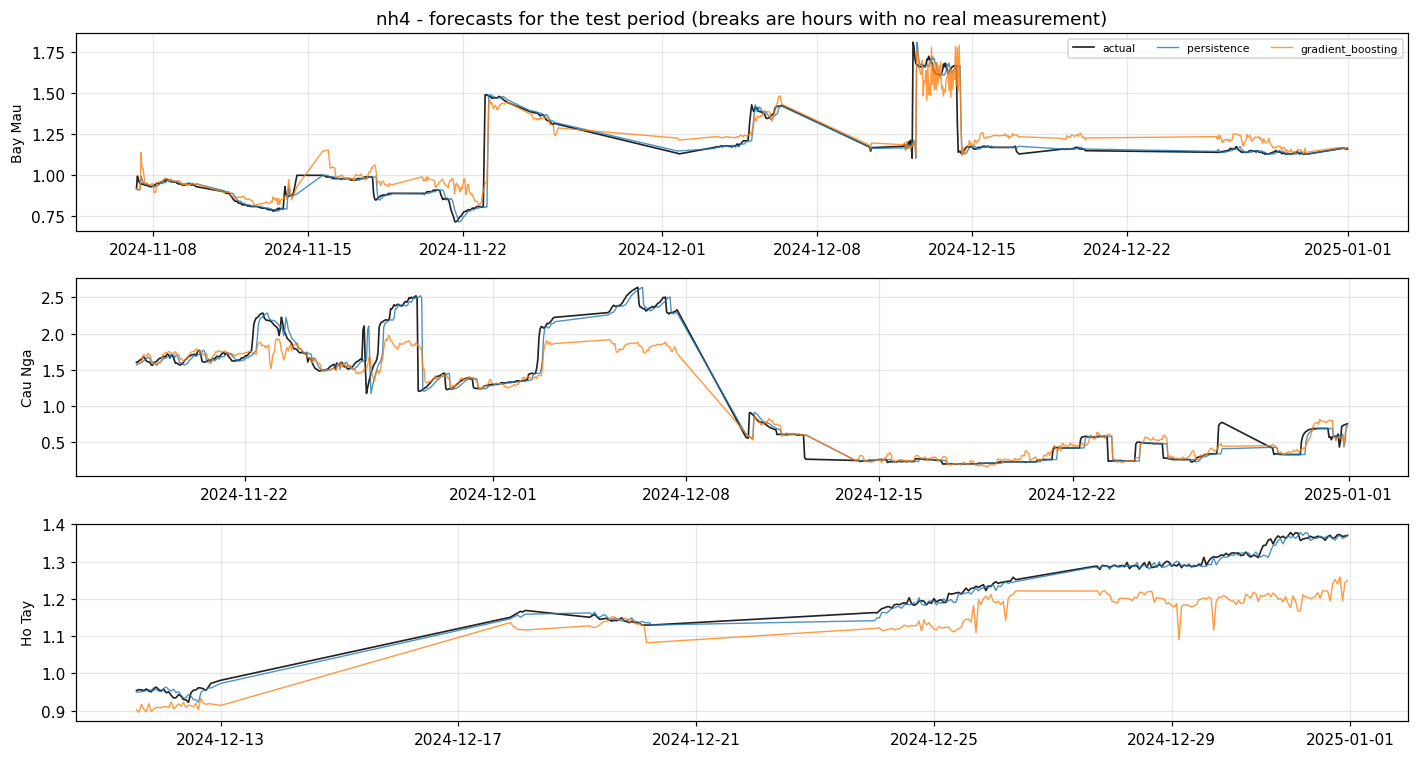

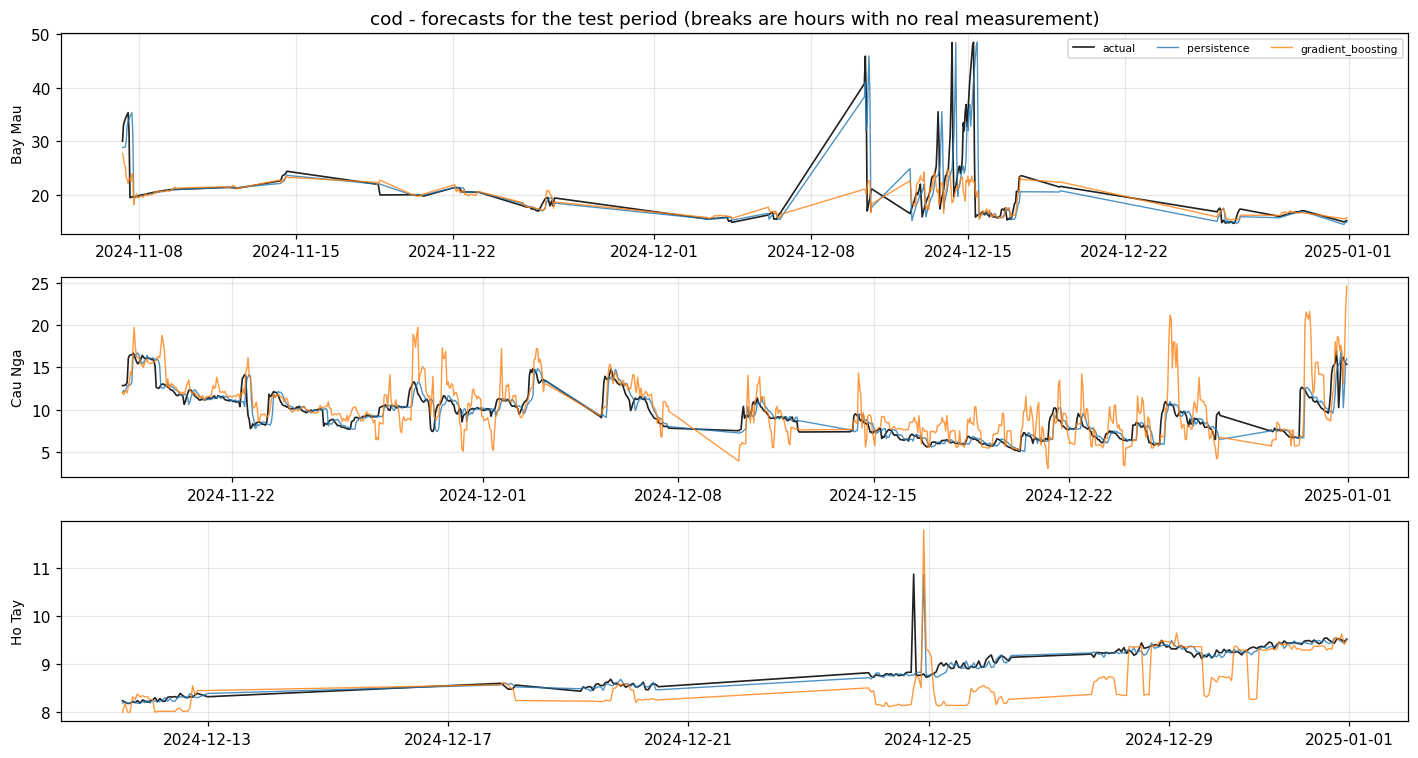

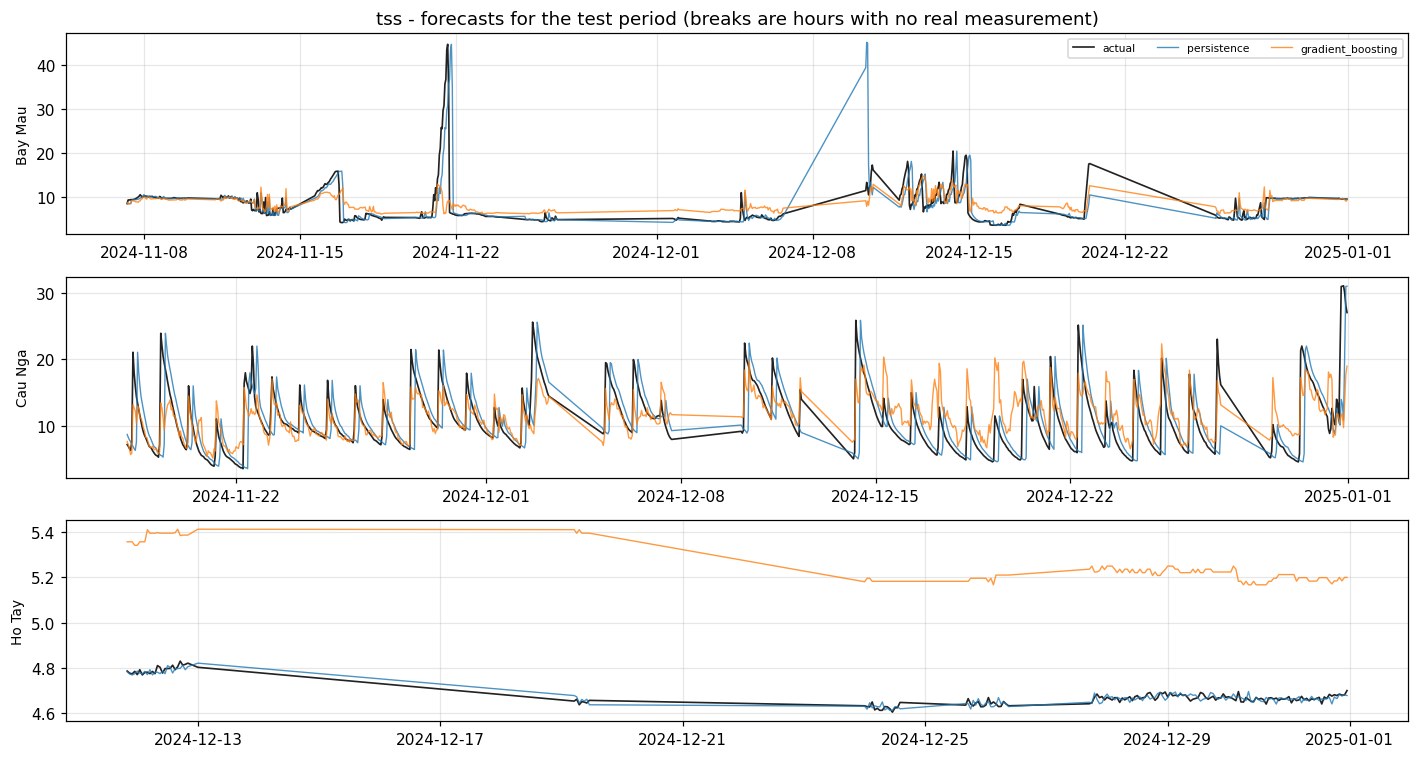

In [9]:
for target in TARGETS:
    figure, axes = plt.subplots(3, 1, figsize=(13, 7))

    for axis, site in zip(axes, SITES):
        table = predictions[(site, target)]
        # Plot at the time being forecast, not the time the forecast was made.
        times = table.index + pd.Timedelta(hours=HORIZON_HOURS)

        axis.plot(times, table["actual"], linewidth=1.1, color="#222", label="actual")
        axis.plot(times, table[BASELINE], linewidth=0.9, alpha=0.8, label=BASELINE)
        axis.plot(times, table["gradient_boosting"], linewidth=0.9, alpha=0.8,
                  label="gradient_boosting")

        axis.set_ylabel(SITE_NAME[site], fontsize=9)
        if site == SITES[0]:
            axis.legend(fontsize=7, ncol=4)

    axes[0].set_title(target + " - forecasts for the test period "
                      "(breaks are hours with no real measurement)")
    plt.tight_layout()
    plt.show()

## Step 9 — Save the results

In [10]:
import os
os.makedirs("results", exist_ok=True)

scores.round(6).to_csv("results/model_scores.csv", index=False)
checks.round(6).to_csv("results/bootstrap_checks.csv", index=False)
decisions.round(6).to_csv("results/final_decision.csv", index=False)

print("Saved:")
print("   results/model_scores.csv     - accuracy of every model")
print("   results/bootstrap_checks.csv - which improvements are real")
print("   results/final_decision.csv   - the model to keep for each case")

Saved:
   results/model_scores.csv     - accuracy of every model
   results/bootstrap_checks.csv - which improvements are real
   results/final_decision.csv   - the model to keep for each case


## Conclusions

### Why compare against a baseline at all?

Because accuracy on its own cannot tell you whether a model is useful. Every model here scores
a high R2 on NH4, but only because NH4 barely changes in 4 hours (notebook 01, Step 7). The
skill score removes that illusion by asking a better question: *is this model better than
assuming nothing changes?*

### What the answer turned out to be

The baseline was kept in most cases. Where a model did win, it was `gradient_boosting` or
`moving_average` — both far cheaper to train than a neural network.

For those cases the forecasting system is one line of code:

```
forecast for 4 hours from now = the value measured right now
```

No training, no retraining schedule, no feature pipeline, and nothing to go wrong except a
missing sensor reading.

### Is that a bad result?

No. It is a cheap, reliable system **plus evidence for why nothing more complicated was
needed**. That evidence is the deliverable. Without a baseline, a model reporting R2 = 0.99
looks like a success even when it is worse than doing nothing at all.

### What to try next

1. **Forecast further ahead.** At 4 hours these indicators hardly move, which limits how much
   any model can win. At 24 or 48 hours persistence gets much weaker and a real model has room
   to prove itself. This is the most promising change.
2. **Fix the gaps at Ho Tay.** Only a few hundred hours could honestly be tested there, which
   is too few to be confident about.
3. **Predict events instead of values.** For example: *will NH4 go above the safety limit in
   the next 24 hours?* That is more useful in practice, and it cannot be won by copying the
   last value.